In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt
from torch_uncertainty.losses import ELBOLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST("../experiment_files/data",train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST("../experiment_files/data",train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


In [3]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

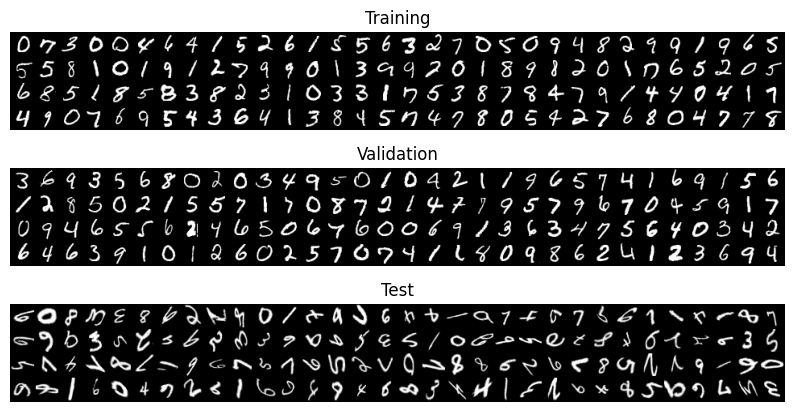

In [4]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [5]:
from torch_uncertainty.routines import ClassificationRoutine

In [6]:
from torch_uncertainty.utils.trainer import TUTrainer

In [7]:
import sys
from lightning.pytorch.callbacks import TQDMProgressBar


class MyProgressBar2(TQDMProgressBar):
    def init_validation_tqdm(self):
        bar = super().init_validation_tqdm()
        if not sys.stdout.isatty():
            bar.disable = True
        return bar

    def init_predict_tqdm(self):
        bar = super().init_predict_tqdm()
        if not sys.stdout.isatty():
            bar.disable = True
        return bar

    def init_test_tqdm(self):
        bar = super().init_test_tqdm()
        if not sys.stdout.isatty():
            bar.disable = True
        return bar


In [8]:

import os
from torch_uncertainty.layers.bayesian import BayesLinear,BayesConv2d

model_path = f'../model/{dataset}_bayes.pth'

model = nn.Sequential(
    BayesConv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    BayesConv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    BayesLinear(64 * 7 * 7, 128),
    nn.GELU(),
    BayesLinear(128, 10),
)
loss = ELBOLoss(
    model,inner_loss=nn.CrossEntropyLoss(),kl_weight=1 / 10000,num_samples=3,
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = ClassificationRoutine(model,num_classes=10,loss=loss, optim_recipe=torch.optim.AdamW(model.parameters(), lr=1e-3))
    progress_bar = MyProgressBar2()
    trainer = TUTrainer(
        accelerator="cuda",
        max_epochs=3,
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

INFO:pytorch_lightning.utilities.rank_zero:Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Training model and will save to ../model/mnist_bayes.pth


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | ood_criterion    | MaxSoftmaxCriterion | 0      | train
1 | model            | Sequential          | 843 K  | train
2 | loss             | ELBOLoss            | 843 K  | train
3 | format_batch_fn  | Identity            | 0      | train
4 | val_cls_metrics  | MetricCollection    | 0      | train
5 | test_cls_metrics | MetricCollection    | 0      | train
6 | test_id_entropy  | Entropy             | 0      | train
7 | mixup            | Identity            | 0      | train
-----------------------------------------------------------------
843 K     Trainable params
0         Non-trainable params
843 K     Total params
3.373     Total estimated model params size (MB)
54        Modules in train mode
0         Modules in eval mode


Epoch 2: 100%|██████████| 469/469 [00:21<00:00, 21.40it/s, v_num=5, train_loss=23.00, Acc=98.50]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


Epoch 2: 100%|██████████| 469/469 [00:21<00:00, 21.37it/s, v_num=5, train_loss=23.00, Acc=98.50]
Model saved to ../model/mnist_bayes.pth


In [ ]:
# Performance is worse than non bayesian by not a small margin.